In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from spatialkfold.clusters import spatial_kfold_clusters
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
sample_metadata = pd.read_csv("../data/share/sample_metadata.csv", index_col=0)
y = sample_metadata["picoplankton_province"]

baseline_samples = pd.read_csv("../data/share//sample_scenarios/baseline_samples.csv", index_col="index")
X = baseline_samples

In [3]:
columns_to_remove1 = ['DiffuseAttenuationCoefficientPAR', 'MixedLayerDepth', 'SeaWaterSpeed', 'PhotosyntheticallyAvailableRadiation', 'Terrain']
X = X[[col for col in X.columns if col not in columns_to_remove1]]

columns_to_remove2 = ['AirTemperature', 'SeaIceThickness', 'TotalCloudFraction', 'TotalPhytoplankton']
X = X[[col for col in X.columns if col not in columns_to_remove2]]

In [4]:
clf = RandomForestClassifier(random_state=4)

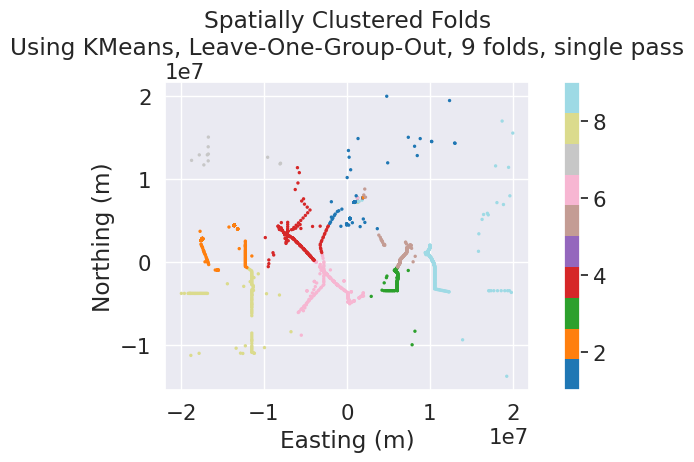

In [27]:
# Spatial Block Cross-Validation

gdf = gpd.GeoDataFrame(
    X.copy(),
    geometry=gpd.points_from_xy(sample_metadata["longitude"], sample_metadata["latitude"]),
    crs="EPSG:4326"
)
gdf_prj = gdf.to_crs("EPSG:3395")
gdf_prj['id'] = range(len(gdf_prj))

# Spatial cluster resampling 
clusters = spatial_kfold_clusters(
    gdf=gdf_prj,
    name='id',
    nfolds=9,
    algorithm='kmeans',
    n_init="auto",
    random_state=4
    )

# Find row positions of BALT samples
balt_positions = np.where(y.values == "BALT")[0]
# Reassign BALT to random folds with fixed seed, avoid being isolated in a single fold
clusters.iloc[balt_positions, clusters.columns.get_loc('folds')] = (
    np.random.default_rng(4).integers(1, 10, size=len(balt_positions)).astype(clusters['folds'].dtype)
)

cv = LeaveOneGroupOut()
groups = clusters['folds'].values

cols_tab = plt.get_cmap('tab20', 10)
cols = [cols_tab(i) for i in range(10)]
color_ramp = ListedColormap(cols)

fig, ax = plt.subplots(1,1, figsize=(9, 4))
clusters.plot(column='folds', ax=ax, cmap=color_ramp, markersize=2, legend=True)
ax.set_title('Spatially Clustered Folds\nUsing KMeans, Leave-One-Group-Out, 9 folds, single pass')
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.savefig("../outputs/figures/sample/spatial_block_cv_folds_map.png", bbox_inches="tight", dpi=300)
plt.show()

In [17]:
pd.crosstab(clusters['folds'].values, y.values)

col_0,APLR,BALT,BPLR,CTEM,MTEM,OTEM,STEM,TGYR,TRHI,TRLO
row_0,,,,,,,,,,
1,0,3,16,40,56,1,7,1,0,0
2,0,6,0,93,0,0,0,0,37,94
3,2,2,0,0,0,0,0,12,0,118
4,0,5,5,0,7,7,0,11,3,183
5,0,8,0,0,0,0,0,0,0,134
6,1,7,0,3,19,25,18,58,0,74
7,0,4,11,0,0,0,0,0,0,0
8,25,4,0,2,0,10,9,43,14,0
9,2,12,10,1,0,0,0,36,0,215


In [19]:
all_labels = sorted(y.unique())
confusion_matrices, accuracies = [], []
feature_importances = []

for i, (train_index, test_index) in enumerate(cv.split(X, y, groups)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    confusion_mat = confusion_matrix(y_test, y_pred, labels=all_labels, normalize="pred")
    confusion_matrices.append(confusion_mat)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    feature_importances.append(clf.feature_importances_)

In [23]:
confusion = np.mean(np.stack(confusion_matrices), axis=0)
confusion = pd.DataFrame(confusion, index=all_labels, columns=all_labels)

confusion_sd = np.std(np.stack(confusion_matrices), axis=0)
confusion_sd = pd.DataFrame(confusion_sd, index=all_labels, columns=all_labels)

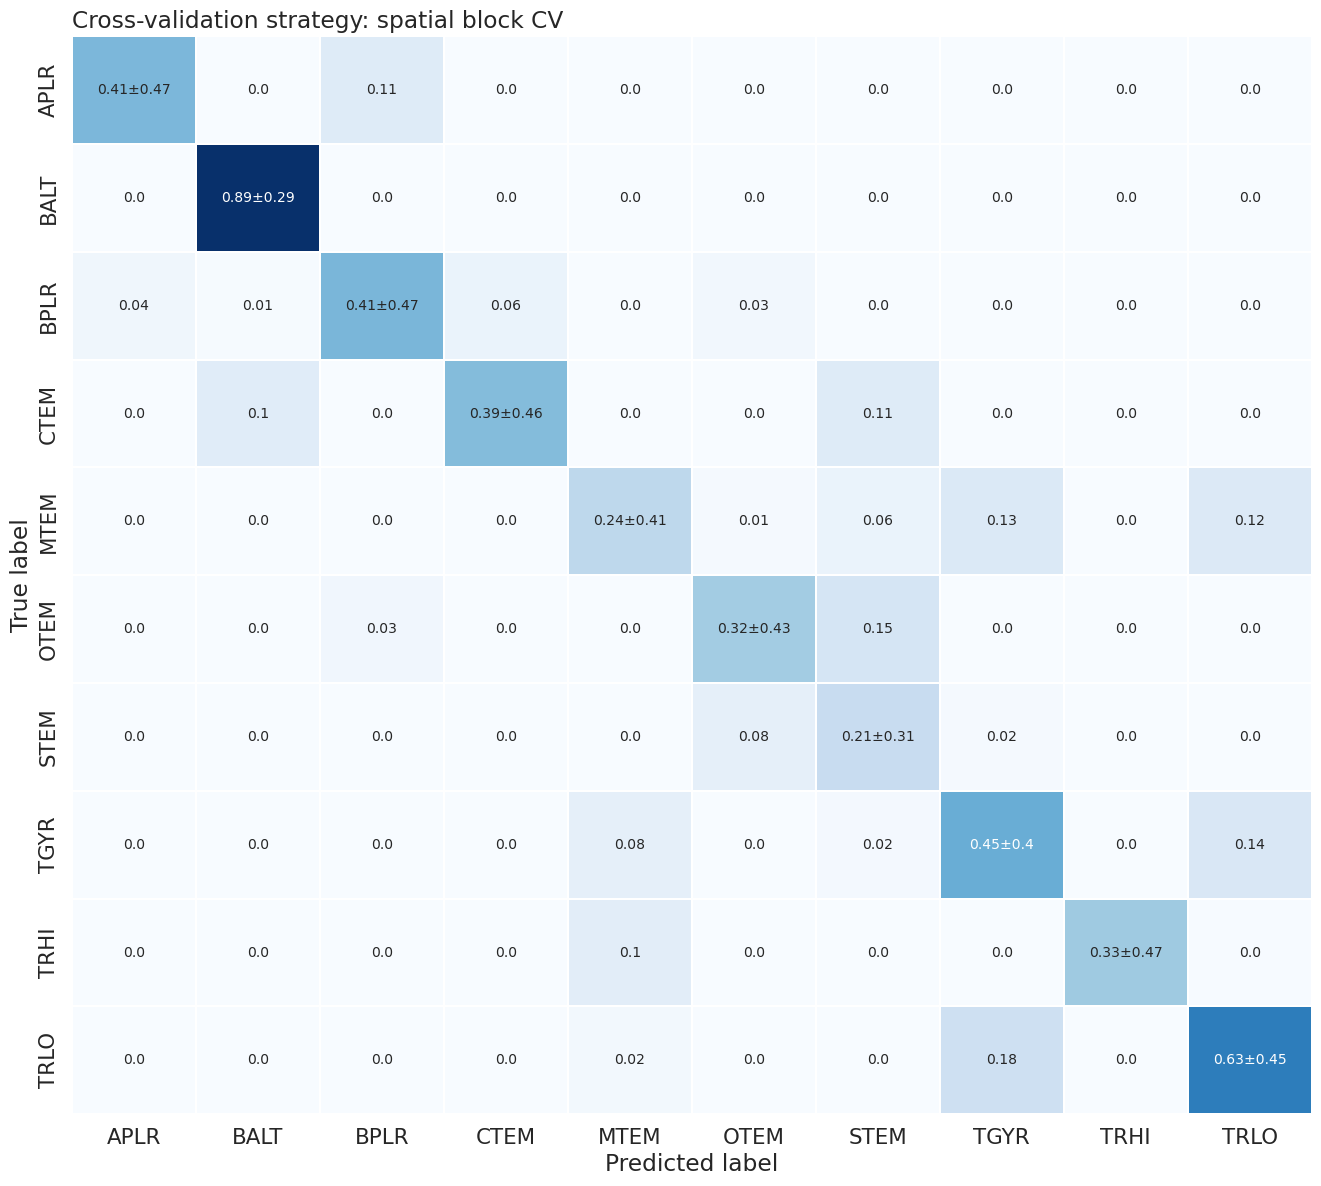

In [28]:
def create_annot_text(mean_df, sd_df):
    annot = mean_df.round(2).astype(str)
    for i in range(len(mean_df)):
        annot.iloc[i, i] += "±" + str(round(sd_df.iloc[i, i], 2))
    return annot

annot_text = create_annot_text(confusion, confusion_sd)   

fig, ax = plt.subplots(figsize=(16, 14))
sns.set(font_scale=1.4)
sns.heatmap(
    confusion,
    annot=annot_text,
    fmt="",
    cmap=plt.cm.Blues,
    linewidths=0.2,
    ax=ax,
    annot_kws={"size": 10},
    cbar=False
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    "Cross-validation strategy: spatial block CV",
    loc="left",
)

ax.set_title(
    "Cross-validation strategy: spatial block CV",
    loc="left",
)
plt.savefig("../outputs/figures/sample/spatial_block_cv_confusion_matrix.png", bbox_inches="tight", dpi=300)

In [25]:
pd.DataFrame({"accuracy": accuracies, "cv_method": "spatial_block_cv"}).to_csv(
    "../outputs/tables/sample/spatial_block_cv_scores.csv", index=False
)

In [26]:
for i, (train_index, test_index) in enumerate(cv.split(X, y, groups)):
    held_out_fold = groups[test_index][0]
    print(f"iteration {i}: held-out fold = {held_out_fold}, accuracy = {accuracies[i]:.3f}")

iteration 0: held-out fold = 1, accuracy = 0.492
iteration 1: held-out fold = 2, accuracy = 0.974
iteration 2: held-out fold = 3, accuracy = 0.910
iteration 3: held-out fold = 4, accuracy = 0.923
iteration 4: held-out fold = 5, accuracy = 1.000
iteration 5: held-out fold = 6, accuracy = 0.746
iteration 6: held-out fold = 7, accuracy = 1.000
iteration 7: held-out fold = 8, accuracy = 0.850
iteration 8: held-out fold = 9, accuracy = 0.931
